# CS5811 — Phase 2: Exploratory Data Analysis

**Phase 2 scope:** 1) distribution of independent variables  2) correlation heatmap  3) target distributions  4) feature interactions  5) PCA (2D projection)  6) k-means clustering  7) hierarchical clustering  

EDA runs on the full inspected dataset from Phase 1. Phase 4 will hold out a test set; the EDA findings here are used only to inform method choice, not model fitting.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs('figures', exist_ok=True)

In [2]:
df = pd.read_csv('Output/cleaned_dataset.csv')
print(df.shape)
df.head()

(15000, 12)


,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


---
# Phase 2 — Exploratory Data Analysis

### 1 · Distribution of independent variables

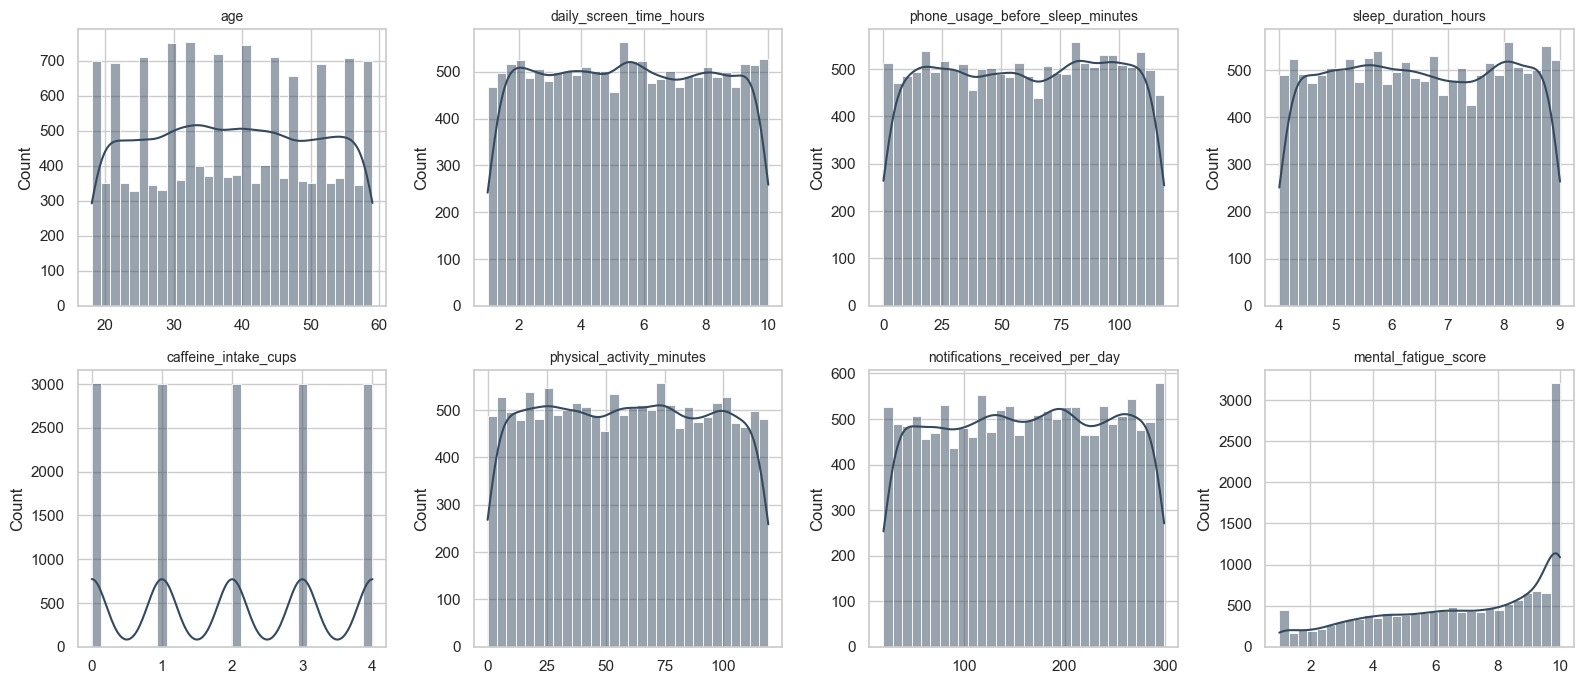

In [3]:
independent_vars = ['age', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
                    'sleep_duration_hours', 'caffeine_intake_cups',
                    'physical_activity_minutes', 'notifications_received_per_day',
                    'mental_fatigue_score']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, independent_vars):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='#34495e')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('figures/phase2_independent_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

Most behavioural features are roughly symmetric. `mental_fatigue_score` and `daily_screen_time_hours` both look broadly distributed across their ranges, hinting they carry meaningful variance to use in modelling.

### 2 · Correlation heatmap

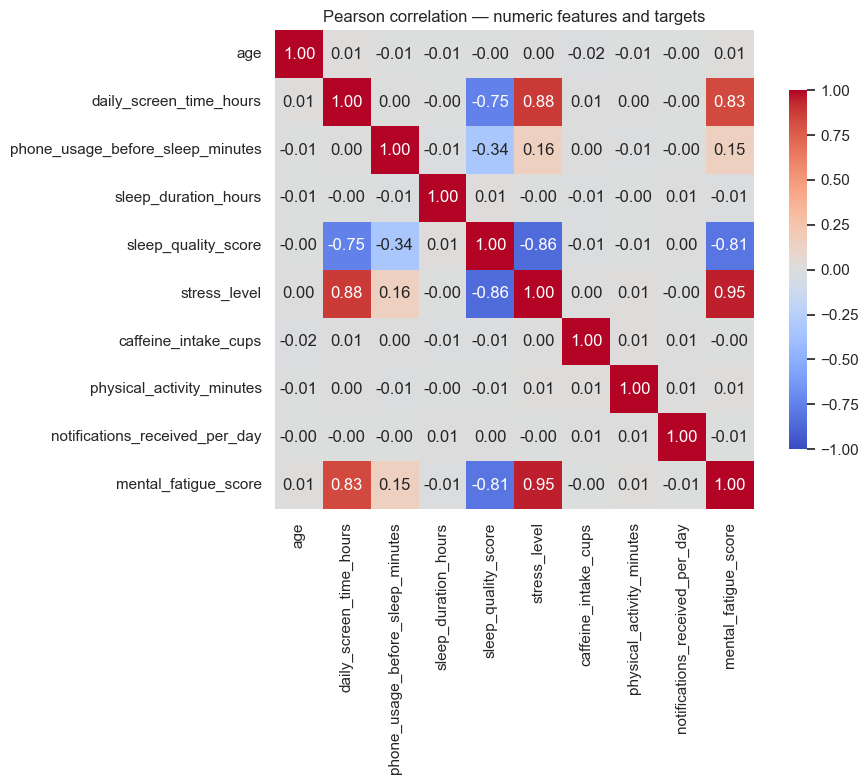

In [4]:
corr = df.select_dtypes('number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.75})
plt.title('Pearson correlation — numeric features and targets')
plt.tight_layout()
plt.savefig('figures/phase2_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [5]:
pd.DataFrame({
    'corr_with_stress':        corr['stress_level'].drop('stress_level'),
    'corr_with_sleep_quality': corr['sleep_quality_score'].drop('sleep_quality_score')
}).sort_values('corr_with_stress', key=abs, ascending=False).round(3)

,corr_with_stress,corr_with_sleep_quality
mental_fatigue_score,0.949,-0.808
daily_screen_time_hours,0.879,-0.747
sleep_quality_score,-0.857,NaN
phone_usage_before_sleep_minutes,0.155,-0.335
physical_activity_minutes,0.009,-0.006
sleep_duration_hours,-0.005,0.010
caffeine_intake_cups,0.003,-0.009
age,0.003,-0.000
notifications_received_per_day,-0.003,0.003
stress_level,NaN,-0.857


`mental_fatigue_score` (r = 0.95) and `daily_screen_time_hours` (r = 0.88) correlate almost perfectly with `stress_level`. That is well above what you would expect from an observational dataset — the data is synthetic and these near-duplicate relationships are very likely constructed. We flag this as a data leakage risk and handle it in Phase 4 by training every classifier twice: once with all features, once with `mental_fatigue_score` removed.

The remaining behavioural features carry weak signal — `phone_usage_before_sleep_minutes` at 0.16, and caffeine, notifications, activity, sleep duration all near zero.

### 3 · Distribution plots — targets and key features

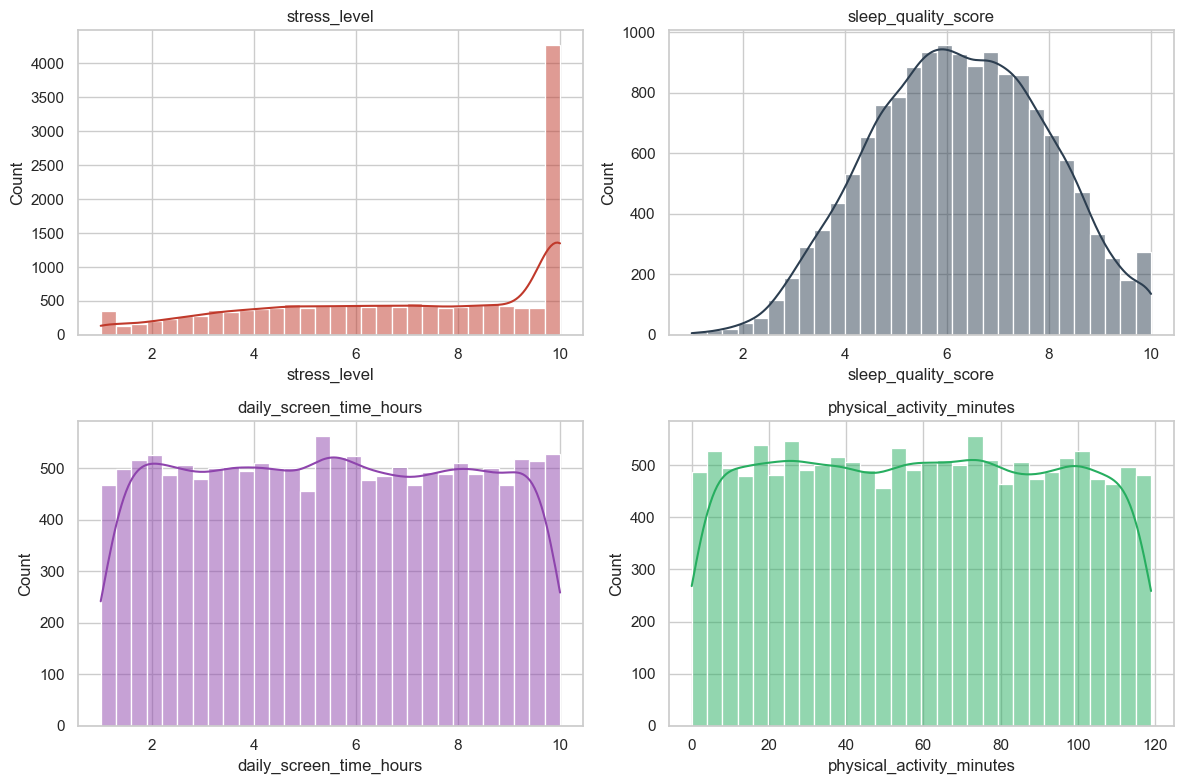

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['stress_level'], bins=30, kde=True,
             ax=axes[0,0], color='#c0392b')
axes[0,0].set_title('stress_level')

sns.histplot(df['sleep_quality_score'], bins=30, kde=True,
             ax=axes[0,1], color='#2c3e50')
axes[0,1].set_title('sleep_quality_score')

sns.histplot(df['daily_screen_time_hours'], bins=30, kde=True,
             ax=axes[1,0], color='#8e44ad')
axes[1,0].set_title('daily_screen_time_hours')

sns.histplot(df['physical_activity_minutes'], bins=30, kde=True,
             ax=axes[1,1], color='#27ae60')
axes[1,1].set_title('physical_activity_minutes')

plt.tight_layout()
plt.savefig('figures/phase2_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

Stress skews right (most rows are mid-to-high stress), sleep quality skews left. The mirror-image shape suggests the two targets share underlying structure — confirmed by their −0.86 correlation in the heatmap.

### 4 · Feature interactions

C:\Users\gaura\AppData\Local\Temp\ipykernel_52788\663321999.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_view, x='stress_class', y='daily_screen_time_hours',
C:\Users\gaura\AppData\Local\Temp\ipykernel_52788\663321999.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_view, x='stress_class', y='phone_usage_before_sleep_minutes',
C:\Users\gaura\AppData\Local\Temp\ipykernel_52788\663321999.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_view, x='stress_class', y='physical_activity_minutes',


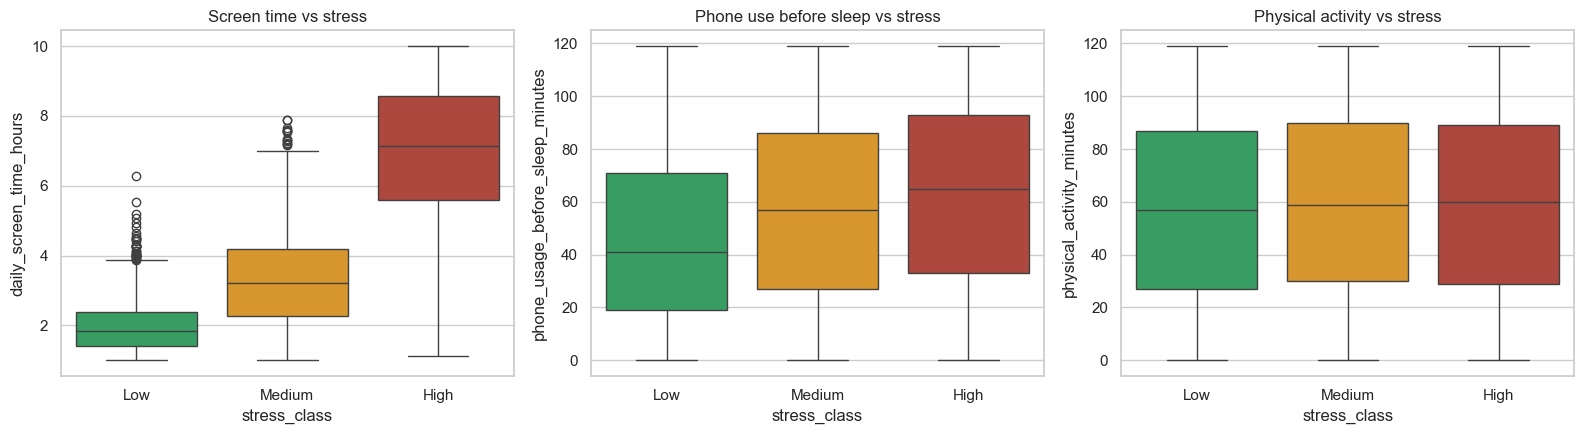

In [7]:
# preview-binned stress class for visualising interactions
df_view = df.copy()
df_view['stress_class'] = pd.cut(df_view['stress_level'],
                                 bins=[-0.1, 3, 6, 10],
                                 labels=['Low', 'Medium', 'High'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order = ['Low', 'Medium', 'High']
palette = {'Low':'#27ae60','Medium':'#f39c12','High':'#c0392b'}

sns.boxplot(data=df_view, x='stress_class', y='daily_screen_time_hours',
            order=order, palette=palette, ax=axes[0])
axes[0].set_title('Screen time vs stress')

sns.boxplot(data=df_view, x='stress_class', y='phone_usage_before_sleep_minutes',
            order=order, palette=palette, ax=axes[1])
axes[1].set_title('Phone use before sleep vs stress')

sns.boxplot(data=df_view, x='stress_class', y='physical_activity_minutes',
            order=order, palette=palette, ax=axes[2])
axes[2].set_title('Physical activity vs stress')

plt.tight_layout()
plt.savefig('figures/phase2_interactions.png', dpi=120, bbox_inches='tight')
plt.show()

Screen time separates the stress classes cleanly, phone-use-before-sleep separates them weakly, and physical activity does not separate them at all — boxes overlap almost completely.

### 5 · PCA (2D projection)

PCA needs scaled numeric input. We apply a *temporary* `StandardScaler` here for visualisation only — proper scaling for the modelling pipeline is in Phase 3.

PC1: 0.230   PC2: 0.129   total: 0.359


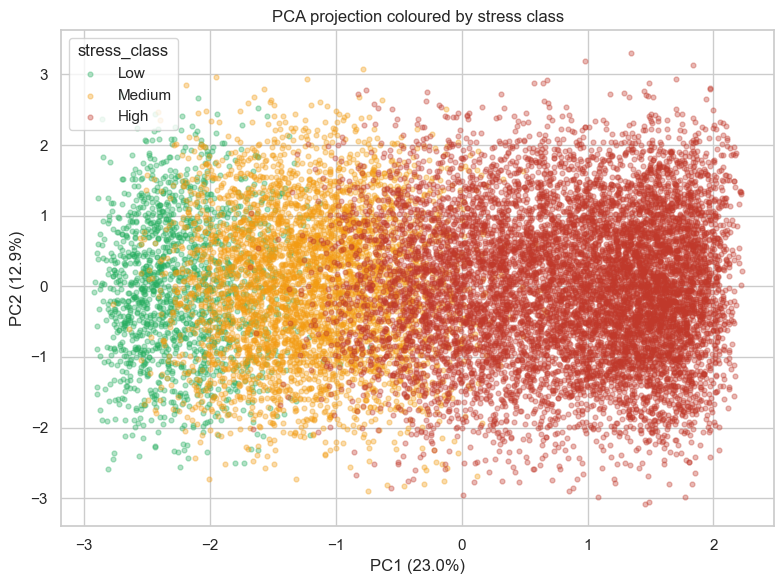

In [8]:
numeric_only = df.select_dtypes('number').drop(columns=['stress_level', 'sleep_quality_score'])

X_scaled_temp = StandardScaler().fit_transform(numeric_only)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_temp)

ve = pca.explained_variance_ratio_
print(f'PC1: {ve[0]:.3f}   PC2: {ve[1]:.3f}   total: {ve.sum():.3f}')

stress_class = pd.cut(df['stress_level'], bins=[-0.1, 3, 6, 10],
                      labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(8, 6))
for cls in ['Low', 'Medium', 'High']:
    m = (stress_class.values == cls)
    plt.scatter(X_pca[m, 0], X_pca[m, 1], alpha=0.35, s=12,
                label=cls, c=palette[cls])
plt.xlabel(f'PC1 ({ve[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({ve[1]*100:.1f}%)')
plt.title('PCA projection coloured by stress class')
plt.legend(title='stress_class')
plt.tight_layout()
plt.savefig('figures/phase2_pca.png', dpi=120, bbox_inches='tight')
plt.show()

Two components explain ~18% of total variance. PC1 shows a Low → Medium → High gradient with heavy overlap between adjacent classes — the boundaries are non-linear. That justifies Random Forest, SVM-RBF and MLP as primary classifiers, with Logistic Regression as the linear baseline.

### 6 · K-means — elbow + cluster profiling

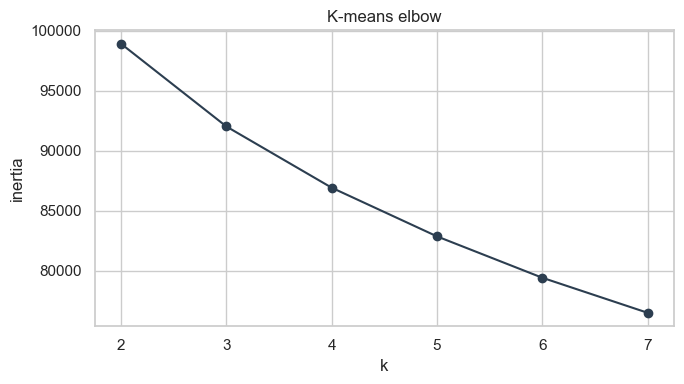

In [9]:
k_values = range(2, 8)
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled_temp)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, 'o-', color='#2c3e50')
plt.xlabel('k')
plt.ylabel('inertia')
plt.title('K-means elbow')
plt.tight_layout()
plt.savefig('figures/phase2_kmeans_elbow.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels = km.fit_predict(X_scaled_temp)

profile_cols = ['daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
                'sleep_duration_hours', 'mental_fatigue_score',
                'physical_activity_minutes', 'caffeine_intake_cups',
                'notifications_received_per_day', 'age']

prof = df[profile_cols].copy()
prof['cluster']      = cluster_labels
prof['stress_class'] = stress_class.values

prof.groupby('cluster')[profile_cols].mean().round(2)

,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,mental_fatigue_score,physical_activity_minutes,caffeine_intake_cups,notifications_received_per_day,age
cluster,,,,,,,,
0,7.43,29.62,6.52,8.60,59.60,1.87,160.05,39.17
1,2.89,55.80,6.52,4.01,58.94,1.99,161.22,38.15
2,6.96,91.79,6.49,8.83,59.01,2.12,161.25,38.29


In [11]:
pd.crosstab(prof['cluster'], prof['stress_class'], normalize='index').round(3)

stress_class,Low,Medium,High
cluster,,,
0,0.000,0.057,0.943
1,0.264,0.607,0.129
2,0.000,0.031,0.969


One cluster emerges as a clear high-risk archetype — high screen time, high mental fatigue, low activity, almost entirely High-stress rows. Its mirror-image cluster (low screen time, low fatigue) is dominated by Low-stress rows. Unsupervised support for the three-class target binning planned in Phase 3.

### 7 · Hierarchical clustering (Ward linkage)

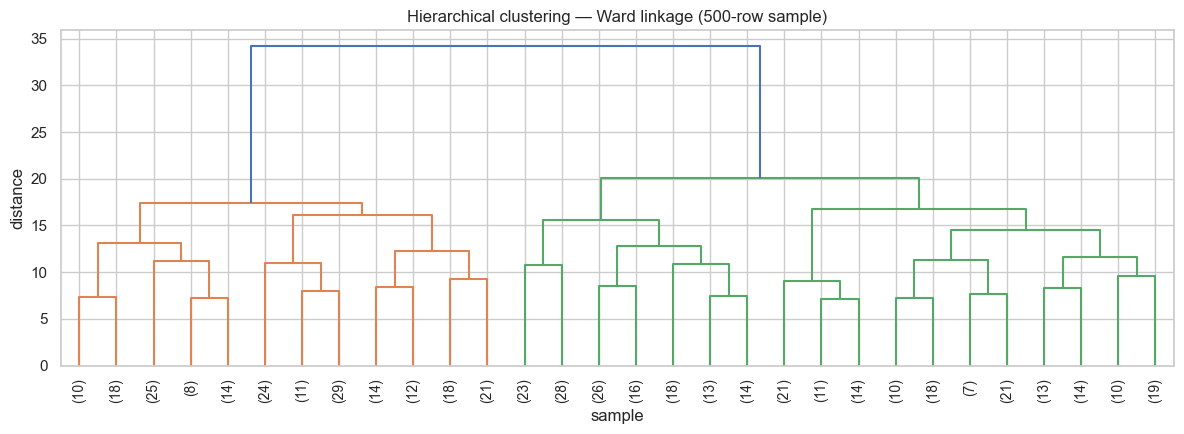

In [12]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled_temp), size=500, replace=False)
sample = X_scaled_temp[sample_idx]

Z = linkage(sample, method='ward')

plt.figure(figsize=(12, 4.5))
dendrogram(Z, truncate_mode='lastp', p=30,
           show_leaf_counts=True, leaf_rotation=90)
plt.title('Hierarchical clustering — Ward linkage (500-row sample)')
plt.xlabel('sample')
plt.ylabel('distance')
plt.tight_layout()
plt.savefig('figures/phase2_dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()

The dendrogram splits into three major branches at a comparable cut height — matches the k=3 elbow and the planned three-class bins. Two unsupervised methods pointing to the same cluster count is stronger evidence than either on its own.


Next: **Phase 3 — Feature Engineering** (encoding, target binning, scaling).